In [1]:
!pip install ultralytics gdown opencv-python matplotlib easyocr cryptography pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 29.8 MB/s eta 0:00:00


In [2]:
import os
import cv2
import yaml
import shutil
import gdown
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
import easyocr
from google.colab import drive

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
PROJECT_DIR = "/content/drive/MyDrive/ANPR_YOLO_PROJECT"
os.makedirs(PROJECT_DIR, exist_ok=True)

In [6]:
import kagglehub

path = kagglehub.dataset_download("ronakgohil/license-plate-dataset")

print("Dataset:", path)

Using Colab cache for faster access to the 'license-plate-dataset' dataset.
Dataset: /kaggle/input/license-plate-dataset


In [7]:
for root, dirs, files in os.walk(path):

    print("\nFOLDER:", root)

    print("FILES:", files[:5])

    print("-"*50)


FOLDER: /kaggle/input/license-plate-dataset
FILES: []
--------------------------------------------------

FOLDER: /kaggle/input/license-plate-dataset/archive
FILES: ['dataset.yaml', 'classes.txt']
--------------------------------------------------

FOLDER: /kaggle/input/license-plate-dataset/archive/labels
FILES: []
--------------------------------------------------

FOLDER: /kaggle/input/license-plate-dataset/archive/labels/val
FILES: ['video9_110.txt', 'video5_110.txt', 'video6_710.txt', 'video8_1040.txt', 'video8_1450.txt']
--------------------------------------------------

FOLDER: /kaggle/input/license-plate-dataset/archive/labels/train
FILES: ['UP12.txt', 'BR6.txt', 'JK11.txt', 'video11_4470.txt', 'car-wbs-HR99EX6037_00000.txt']
--------------------------------------------------

FOLDER: /kaggle/input/license-plate-dataset/archive/images
FILES: []
--------------------------------------------------

FOLDER: /kaggle/input/license-plate-dataset/archive/images/val
FILES: ['video9_40

In [8]:
txt_files = []

for root, dirs, files in os.walk(path):

    for file in files:

        if file.endswith(".txt"):

            txt_files.append(os.path.join(root, file))

print("Total TXT Labels:", len(txt_files))

print(txt_files[:10])

Total TXT Labels: 1696
['/kaggle/input/license-plate-dataset/archive/classes.txt', '/kaggle/input/license-plate-dataset/archive/labels/val/video9_110.txt', '/kaggle/input/license-plate-dataset/archive/labels/val/video5_110.txt', '/kaggle/input/license-plate-dataset/archive/labels/val/video6_710.txt', '/kaggle/input/license-plate-dataset/archive/labels/val/video8_1040.txt', '/kaggle/input/license-plate-dataset/archive/labels/val/video8_1450.txt', '/kaggle/input/license-plate-dataset/archive/labels/val/video8_1600.txt', '/kaggle/input/license-plate-dataset/archive/labels/val/video9_130.txt', '/kaggle/input/license-plate-dataset/archive/labels/val/video5_70.txt', '/kaggle/input/license-plate-dataset/archive/labels/val/video8_1430.txt']


In [9]:
image_extensions = (".jpg", ".jpeg", ".png")

all_images = []

for root, dirs, files in os.walk(path):

    for file in files:

        if file.lower().endswith(image_extensions):

            all_images.append(os.path.join(root, file))

print("Total Images:", len(all_images))

from sklearn.model_selection import train_test_split

train_images, val_images = train_test_split(all_images, test_size=0.2, random_state=42)

print("Train:", len(train_images))
print("Val:", len(val_images))

Total Images: 1695
Train: 1356
Val: 339


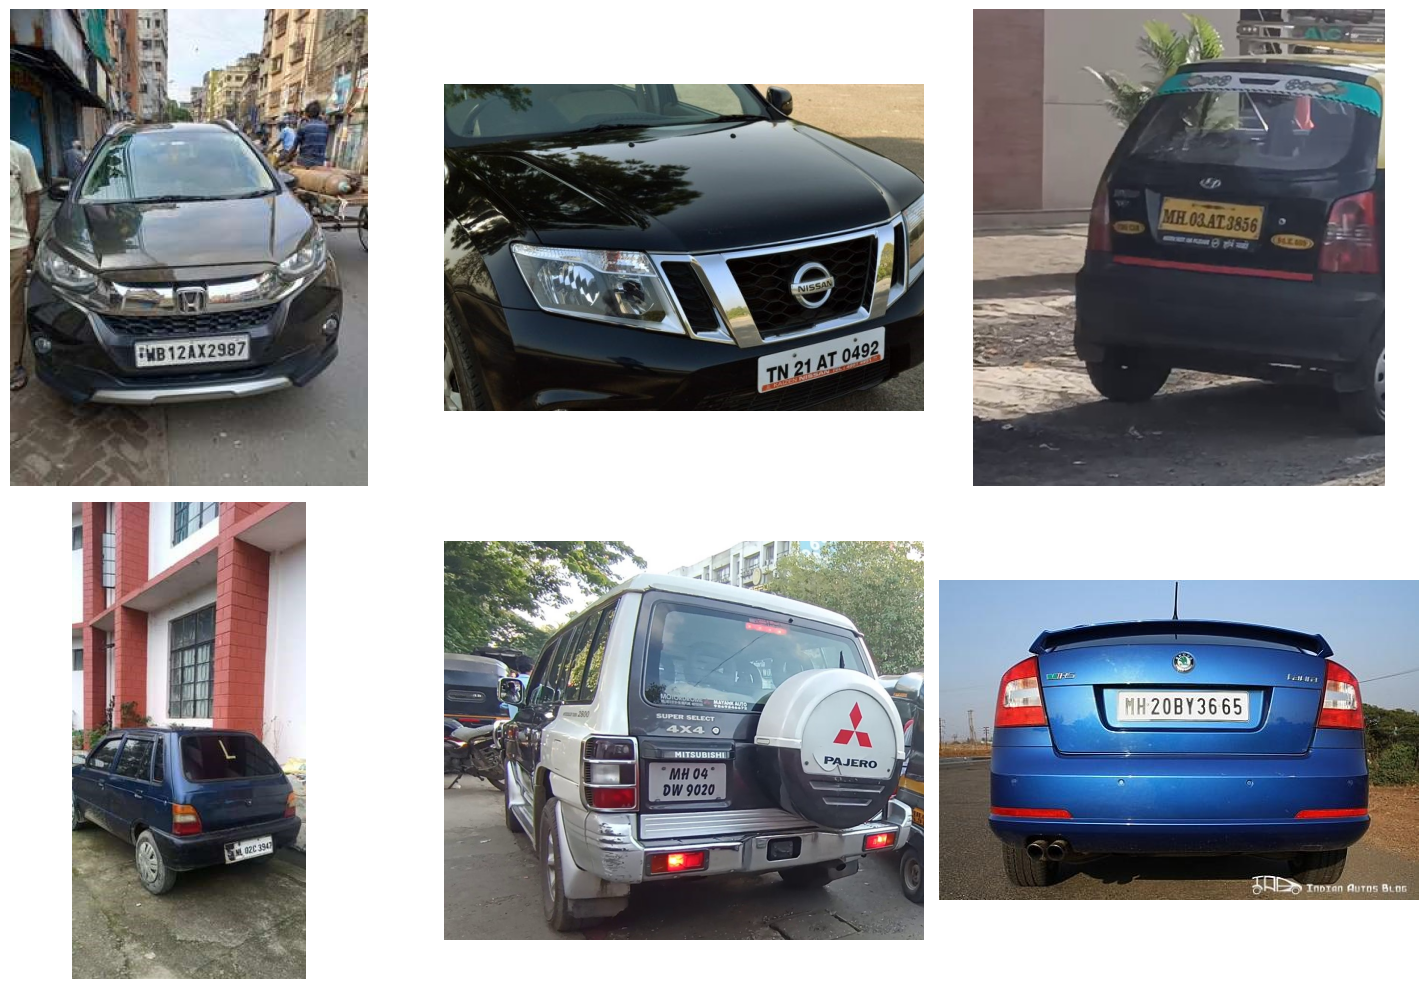

In [11]:
import random
random_images = random.sample(all_images, 6)

plt.figure(figsize=(15,10))

for i, img_path in enumerate(random_images):

    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [12]:
data_yaml = {
    "train": f"{path}/archive/images/train",
    "val": f"{path}/archive/images/val",
    "nc": 1,
    "names": ["license_plate"]
}

yaml_path = "/content/data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f)

print("YAML created")

YAML created


In [14]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

results = model.train(

    data="/content/data.yaml",

    epochs=70,

    imgsz=640,

    batch=8,

    optimizer="AdamW",

    lr0=0.001,

    cache=False,

    amp=True,

    pretrained=True,

    device=0,

    plots=True
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspectiv

In [16]:
run_dir = "/content/runs/detect/train-2"

shutil.copy(run_dir + "/weights/best.pt", PROJECT_DIR)
shutil.copy(run_dir + "/results.csv", PROJECT_DIR)
shutil.copy(run_dir + "/confusion_matrix.png", PROJECT_DIR)
shutil.copy(run_dir + "/results.png", PROJECT_DIR)

print("Saved to Drive ✔")

Saved to Drive ✔


In [17]:
model = YOLO(PROJECT_DIR + "/best.pt")
print("Model Loaded")

Model Loaded


In [18]:
df = pd.read_csv(PROJECT_DIR + "/results.csv")

precision = df["metrics/precision(B)"].iloc[-1]
recall = df["metrics/recall(B)"].iloc[-1]
map50 = df["metrics/mAP50(B)"].iloc[-1]
map5095 = df["metrics/mAP50-95(B)"].iloc[-1]

f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

accuracy = map50

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("mAP50:", map50)

Precision: 0.9938
Recall: 0.99408
F1: 0.9939394802807613
mAP50: 0.99441


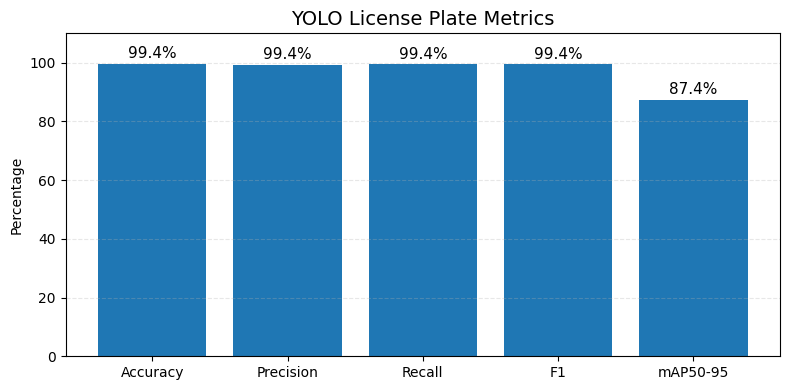

In [25]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1", "mAP50-95"]

values = [
    accuracy * 100,
    precision * 100,
    recall * 100,
    f1 * 100,
    map5095 * 100
]

plt.figure(figsize=(8, 4))

bars = plt.bar(metrics, values)

for i, v in enumerate(values):
    plt.text(
        i,
        v + 2,
        f"{v:.1f}%",
        ha='center',
        fontsize=11
    )

plt.ylim(0, 110)

plt.title("YOLO License Plate Metrics", fontsize=14)
plt.ylabel("Percentage")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from base64 import b64decode
import cv2
import numpy as np
from ultralytics import YOLO
import easyocr

<IPython.core.display.Javascript object>


0: 480x640 1 license_plate, 13.8ms
Speed: 1.6ms preprocess, 13.8ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)


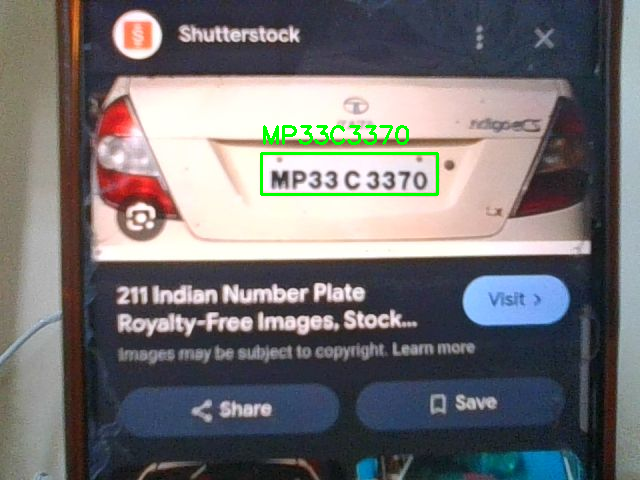

DETECTED NUMBER PLATE:
1. MP33C3370


In [58]:
import cv2
import easyocr
from google.colab.patches import cv2_imshow
from ultralytics import YOLO

model = YOLO(PROJECT_DIR + "/best.pt")
reader = easyocr.Reader(['en'])

image_path = take_photo()
img = cv2.imread(image_path)

results = model(img)

final_texts = []

for r in results:

    for box in r.boxes.xyxy:

        x1, y1, x2, y2 = map(int, box)

        crop = img[y1:y2, x1:x2]

        text = reader.readtext(crop, detail=0)

        plate_text = "".join(text).replace(" ", "")

        if plate_text != "":
            final_texts.append(plate_text)

        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

        cv2.putText(
            img,
            plate_text,
            (x1, y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0,255,0),
            2
        )

cv2_imshow(img)


print("DETECTED NUMBER PLATE:")


if len(final_texts) == 0:
    print("No text detected")
else:
    for i, t in enumerate(final_texts, 1):
        print(f"{i}. {t}")